# Introduction to Data Science 2026

# Week 2

## Exercise 1 | Titanic: data preprocessing and imputation
<span style="font-weight: bold"> *Note: You can find tutorials for NumPy and Pandas under 'Useful tutorials' in the course material.*</span>

Download the [Titanic dataset](https://www.kaggle.com/c/titanic) [train.csv] from Kaggle or <span style="font-weight: 500">directly from the course material</span>, and complete the following exercises. If you choose to download the dataset from Kaggle, you will need to create a Kaggle account unless you already have one, but it is quite straightforward.

The dataset consists of personal information of all the passengers on board the RMS Titanic, along with information about whether they survived the iceberg collision or not.

1. Your first task is to read the data file and print the shape of the data.

    <span style="font-weight: 500"> *Hint 1: You can read them into a Pandas dataframe if you wish.*</span>
    
    <span style="font-weight: 500"> *Hint 2: The shape of the data should be (891, 12).*</span>

In [482]:
import pandas as pd
df = pd.read_csv('train.csv')
print(df.shape)
print(df.describe())


(891, 12)
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


2. Let's look at the data and get started with some preprocessing. Some of the columns, e.g <span style="font-weight: 500"> *Name*</span>, simply identify a person and are not useful for prediction tasks. Try to identify these columns, and remove them.

    <span style="font-weight: 500"> *Hint: The shape of the data should now be (891, 9).*</span>

In [483]:
df = df.drop(["Name", "Ticket", "Fare"], axis=1)
print(df.shape)

(891, 9)


3. The column <span style="font-weight: 500">*Cabin*</span> contains a letter and a number. A smart catch at this point would be to notice that the letter stands for the deck level on the ship. Keeping just the deck information would be more informative when developing, e.g. a classifier that predicts whether a passenger survived. The next step in our preprocessing will be to add a new column to the dataset, which consists simply of the deck letter. You can then remove the original <span style="font-weight: 500">*Cabin*</span>-column.

<span style="font-weight: 500">*Hint: The deck letters should be ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'T'].*</span>

In [484]:
df['Deck'] = df['Cabin'].str[0]
df = df.drop('Cabin', axis=1)
print(df)

     PassengerId  Survived  Pclass     Sex   Age  SibSp  Parch Embarked Deck
0              1         0       3    male  22.0      1      0        S  NaN
1              2         1       1  female  38.0      1      0        C    C
2              3         1       3  female  26.0      0      0        S  NaN
3              4         1       1  female  35.0      1      0        S    C
4              5         0       3    male  35.0      0      0        S  NaN
..           ...       ...     ...     ...   ...    ...    ...      ...  ...
886          887         0       2    male  27.0      0      0        S  NaN
887          888         1       1  female  19.0      0      0        S    B
888          889         0       3  female   NaN      1      2        S  NaN
889          890         1       1    male  26.0      0      0        C    C
890          891         0       3    male  32.0      0      0        Q  NaN

[891 rows x 9 columns]


4. You’ll notice that some of the columns, such as the previously added deck number, are [categorical](https://en.wikipedia.org/wiki/Categorical_variable). To preprocess the categorical variables so that they're ready for further computation, we need to avoid the current string format of the values. This means the next step for each categorical variable is to transform the string values to numeric ones, that correspond to a unique integer ID representative of each distinct category. This process is called label encoding and you can read more about it [here](https://pandas.pydata.org/docs/user_guide/categorical.html).

    <span style="font-weight: 500">*Hint: Pandas can do this for you.*</span>

In [485]:
df['Sex'] = df['Sex'].astype("category")
df['Embarked'] = df['Embarked'].astype("category")
df['Deck'] = df['Deck'].astype("category")
df['Pclass'] = pd.Categorical(df['Pclass'], categories=[3, 2, 1], ordered=True)

print(df['Deck'])
print(df['Embarked'])
print(df['Sex'])
print(df['Pclass'])

0      NaN
1        C
2      NaN
3        C
4      NaN
      ... 
886    NaN
887      B
888    NaN
889      C
890    NaN
Name: Deck, Length: 891, dtype: category
Categories (8, str): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T']
0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: category
Categories (3, str): ['C', 'Q', 'S']
0        male
1      female
2      female
3      female
4        male
        ...  
886      male
887    female
888    female
889      male
890      male
Name: Sex, Length: 891, dtype: category
Categories (2, str): ['female', 'male']
0      3
1      1
2      3
3      1
4      3
      ..
886    2
887    1
888    3
889    1
890    3
Name: Pclass, Length: 891, dtype: category
Categories (3, int64): [3 < 2 < 1]


5. Next, let's look into missing value **imputation**. Some of the rows in the data have missing values, e.g when the cabin number of a person is unknown. Most machine learning algorithms have trouble with missing values, and they need to be handled during preprocessing:

    a) For continuous variables, replace the missing values with the mean of the non-missing values of that column.

    b) For categorical variables, replace the missing values with the mode of the column.

    <span style="font-weight: 500">*Remember: Even though in the previous step we transformed categorical variables into their numeric representation, they are still categorical.*</span>

In [486]:
print(df)
print(df.isnull().sum())
e_mode = df['Embarked'].mode()[0]
d_mode = df['Deck'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(e_mode)
df['Deck'] = df['Deck'].fillna(d_mode)
a_mean = round(df['Age'].mean(), 1)
print(a_mean)
df['Age'] = df['Age'].fillna(a_mean)
print(df.isnull().sum())


     PassengerId  Survived Pclass     Sex   Age  SibSp  Parch Embarked Deck
0              1         0      3    male  22.0      1      0        S  NaN
1              2         1      1  female  38.0      1      0        C    C
2              3         1      3  female  26.0      0      0        S  NaN
3              4         1      1  female  35.0      1      0        S    C
4              5         0      3    male  35.0      0      0        S  NaN
..           ...       ...    ...     ...   ...    ...    ...      ...  ...
886          887         0      2    male  27.0      0      0        S  NaN
887          888         1      1  female  19.0      0      0        S    B
888          889         0      3  female   NaN      1      2        S  NaN
889          890         1      1    male  26.0      0      0        C    C
890          891         0      3    male  32.0      0      0        Q  NaN

[891 rows x 9 columns]
PassengerId      0
Survived         0
Pclass           0
Sex    

6. At this point, all data is numeric. Write the data, with the modifications we made, to a  <span style="font-weight: 500"> .csv</span> file. Then, write another file, this time in <span style="font-weight: 500">JSON</span> format, with the following structure:

In [487]:
#[
#    {
#        "Deck": 0,
#        "Age": 20,
#        "Survived", 0
#        ...
#    },
#    {
#        ...
#    }
#]

In [488]:
from json import loads, dumps
df.to_csv("train_out.csv", index=False)
result = df.to_json(orient='records')
parsed = loads(result)
with open("train.json", "w") as f:
    f.write(dumps(parsed, indent=4)) 

Study the records and try to see if there is any evident pattern in terms of chances of survival.

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 2 | Titanic 2.0: exploratory data analysis

In this exercise, we’ll continue to study the Titanic dataset from the last exercise. Now that we have done some preprocessing, it’s time to look at the data with some exploratory data analysis.

1. First investigate each feature variable in turn. For each categorical variable, find out the mode, i.e., the most frequent value. For numerical variables, calculate the median value.

In [489]:
print(df.describe(include = 'all'))

numerical_variables = ['Age', 'SibSp', 'Parch']
categorical_variables = ['Pclass', 'Sex', 'Embarked', 'Deck']


print(df[numerical_variables].describe().loc['50%'])
print(df[categorical_variables].describe().loc['top'])


        PassengerId    Survived  Pclass   Sex         Age       SibSp  \
count    891.000000  891.000000   891.0   891  891.000000  891.000000   
unique          NaN         NaN     3.0     2         NaN         NaN   
top             NaN         NaN     3.0  male         NaN         NaN   
freq            NaN         NaN   491.0   577         NaN         NaN   
mean     446.000000    0.383838     NaN   NaN   29.699293    0.523008   
std      257.353842    0.486592     NaN   NaN   13.002015    1.102743   
min        1.000000    0.000000     NaN   NaN    0.420000    0.000000   
25%      223.500000    0.000000     NaN   NaN   22.000000    0.000000   
50%      446.000000    0.000000     NaN   NaN   29.700000    0.000000   
75%      668.500000    1.000000     NaN   NaN   35.000000    1.000000   
max      891.000000    1.000000     NaN   NaN   80.000000    8.000000   

             Parch Embarked Deck  
count   891.000000      891  891  
unique         NaN        3    8  
top            NaN

2. Next, combine the modes of the categorical variables, and the medians of the numerical variables, to construct an imaginary “average survivor”. This "average survivor" should represent the typical passenger of the class of passengers who survived. Also following the same principle, construct the “average non-survivor”.

    <span style="font-weight: 500">*Hint 1: What are the average/most frequent variable values for a non-survivor?*</span>
    
    <span style="font-weight: 500">*Hint 2: You can split the dataframe in two: one subset containing all the survivors and one consisting of all the non-survivor instances. Then, you can use the summary statistics of each of these dataframe to create a prototype "average survivor" and "average non-survivor", respectively.*</span>

In [490]:
survivors = df.loc[df['Survived'] == 1]
dead = df.loc[df['Survived'] == 0]

dead_medians = dead[numerical_variables].describe().loc['50%']
dead_modes = dead[categorical_variables].describe().loc['top']

alive_medians = survivors[numerical_variables].describe().loc['50%']
alive_modes = survivors[categorical_variables].describe().loc['top']

average_nonsurvivor = pd.concat([dead_medians, dead_modes], axis=0)
average_survivor = pd.concat([alive_medians, alive_modes], axis=0)
print(average_nonsurvivor)
print(average_survivor)



Age         29.7
SibSp        0.0
Parch        0.0
Pclass         3
Sex         male
Embarked       S
Deck           C
dtype: object
Age           29.7
SibSp          0.0
Parch          0.0
Pclass           1
Sex         female
Embarked         S
Deck             C
dtype: object


3. Next, let's study the distributions of the variables in the two groups (survivor/non-survivor). How well do the average cases represent the respective groups? Can you find actual passengers that are very similar to the (average) representative of their own group? Can you find passengers that are very similar to the (average) representative of the other group?

    <span style="font-weight: 500">*Note: Feel free to choose EDA methods according to your preference: non-graphical/graphical, static/interactive - anything goes.*</span>

In [491]:
survivors.describe(include = 'all')

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked,Deck
count,342.000000,342.0,342.0,342,342.000000,342.000000,342.000000,342,342
unique,NaN,NaN,3.0,2,NaN,NaN,NaN,3,7
top,NaN,NaN,1.0,female,NaN,NaN,NaN,S,C
freq,NaN,NaN,136.0,233,NaN,NaN,NaN,219,241
mean,444.368421,1.0,NaN,NaN,28.549912,0.473684,0.464912,NaN,NaN
std,252.358840,0.0,NaN,NaN,13.772509,0.708688,0.771712,NaN,NaN
min,2.000000,1.0,NaN,NaN,0.420000,0.000000,0.000000,NaN,NaN
25%,250.750000,1.0,NaN,NaN,21.000000,0.000000,0.000000,NaN,NaN
50%,439.500000,1.0,NaN,NaN,29.700000,0.000000,0.000000,NaN,NaN
75%,651.500000,1.0,NaN,NaN,35.000000,1.000000,1.000000,NaN,NaN


In [492]:
dead.describe(include = 'all')

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked,Deck
count,549.000000,549.0,549.0,549,549.000000,549.000000,549.000000,549,549
unique,NaN,NaN,3.0,2,NaN,NaN,NaN,3,8
top,NaN,NaN,3.0,male,NaN,NaN,NaN,S,C
freq,NaN,NaN,372.0,468,NaN,NaN,NaN,427,505
mean,447.016393,0.0,NaN,NaN,30.415301,0.553734,0.329690,NaN,NaN
std,260.640469,0.0,NaN,NaN,12.457359,1.288399,0.823166,NaN,NaN
min,1.000000,0.0,NaN,NaN,1.000000,0.000000,0.000000,NaN,NaN
25%,211.000000,0.0,NaN,NaN,23.000000,0.000000,0.000000,NaN,NaN
50%,455.000000,0.0,NaN,NaN,29.700000,0.000000,0.000000,NaN,NaN
75%,675.000000,0.0,NaN,NaN,35.000000,1.000000,0.000000,NaN,NaN


4. Next, let's continue the analysis by looking into pairwise and multivariate relationships between the variables in the two groups. Try to visualize two variables at a time using, e.g., scatter plots and use a different color to encode the survival status.

    <span style="font-weight: 500">*Hint 1: You can also check out Seaborn's pairplot function, if you wish.*</span>

    <span style="font-weight: 500">*Hint 2: To better show many data points with the same value for a given variable, you can use either transparency or ‘jitter’.*</span>

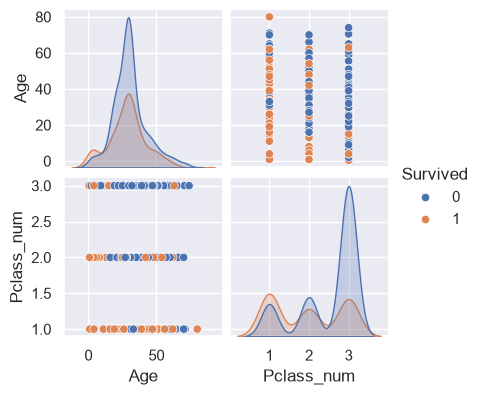

In [493]:
import seaborn as sns
import matplotlib.pyplot as plt

df['Pclass_num'] = df['Pclass'].astype(int)
sns.set()
g = sns.pairplot(df, vars=['Age', 'Pclass_num'], hue="Survived", height =2)
plt.show()

5. Finally, recall the preprocessing we did in the first exercise. What can you say about the effect of the choices that were made to use the mode and mean to impute missing values, instead of, for example, ignoring passengers with missing data?

There was total of 866 missing values of which 177 was in age column and 687 in the new Deck column. The total number of rows were 891 so if we ignored or deleted rows with missing data, we would not have much data to go on with. When it comes to the deck data, it might not be super accurate since we replaced all missing values with mode and there was a lot of missing values. 

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 3 | Working with text data 2.0

This exercise is related to the second exercise from last week. Find the saved <span style="font-weight: 500">pos.txt</span> and <span style="font-weight: 500">neg.txt</span> files, or, alternatively, you can find the week 1 example solutions on the MOOC platform after Tuesday.

1. Find the most common words in each file (positive and negative). Examine the results. Do they tend to be general terms relating to the nature of the data? How well do they indicate positive/negative sentiment?

In [494]:
from collections import Counter

with open("neg.text") as input_file:
    count = Counter(word for line in input_file
                         for word in line.split())

print(count.most_common(10))

with open("pos.text") as input_file:
    count = Counter(word for line in input_file
                         for word in line.split())

print(count.most_common(10))


[('work', 39884), ('use', 37144), ('fit', 31003), ('product', 24220), ('just', 23536), ('light', 22773), ('like', 20661), ('time', 19620), ('look', 18733), ('instal', 18608)]
[('great', 435364), ('work', 427018), ('use', 344505), ('good', 290641), ('fit', 272452), ('instal', 228413), ('product', 209144), ('look', 181015), ('just', 180041), ('like', 175415)]


2. Compute a [TF/IDF](https://en.wikipedia.org/wiki/Tf–idf) vector for each of the two text files, and make them into a <span style="font-weight: 500">2 x m</span> matrix, where <span style="font-weight: 500">m</span> is the number of unique words in the data. The problem with using the most common words in a review to analyze its contents is that words that are common overall will be common in all reviews (both positive and negative). This means that they probably are not good indicators about the sentiment of a specific review. TF/IDF stands for Term Frequency / Inverse Document Frequency (here the reviews are the documents), and is designed to help by taking into consideration not just the number of times a term occurs (term frequency), but also how many times a word exists in other reviews as well (inverse document frequency). You can use any variant of the formula, as well as off-the-shelf implementations. <span style="font-weight: 500">*Hint: You can use [sklearn](http://scikit-learn.org/).*</span>

In [495]:
from sklearn.feature_extraction.text import TfidfVectorizer

with open("pos.text","r") as f:
    pos_corpus = f.read()
    
with open("neg.text","r") as f:
    neg_corpus = f.read()
    
corpus = [pos_corpus, neg_corpus]
    
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)
feature_names = vectorizer.get_feature_names_out()

print(X.shape)

(2, 131669)


3. List the words with the highest TF/IDF score in each class (positive | negative), and compare them to the most common words. What do you notice? Did TF/IDF work as expected?

In [496]:
tfidf = pd.DataFrame(X.toarray(), columns=feature_names, index=['positive', 'negative'])
print(tfidf.loc['positive'].sort_values(ascending=False).head(10))
print(tfidf.loc['negative'].sort_values(ascending=False).head(10))


great      0.365575
work       0.357895
use        0.287715
good       0.244408
fit        0.229495
instal     0.191571
product    0.180139
look       0.152044
just       0.151329
like       0.146537
Name: positive, dtype: float64
work       0.300219
use        0.278418
fit        0.234942
product    0.187239
just       0.177100
light      0.172367
like       0.154589
time       0.147713
look       0.141337
instal     0.140613
Name: negative, dtype: float64


The words are same as the most common words

4. Plot the words in each class with their corresponding TF/IDF scores. Note that there will be a lot of words, so you’ll have to think carefully to make your chart clear! If you can’t plot them all, plot a subset – think about how you should choose this subset.

    <span style="font-weight: 500">*Hint: you can use word clouds. But feel free to challenge yourselves to think of any other meaningful way to visualize this information!*</span>

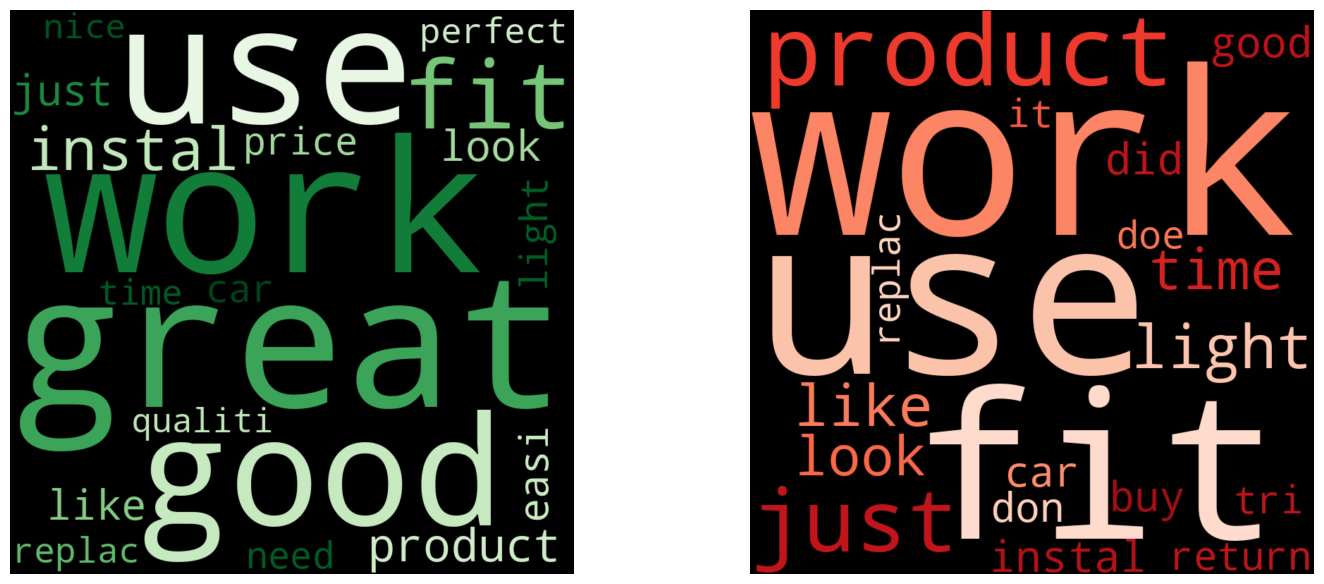

In [497]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

top_neg =tfidf.loc['negative'].sort_values(ascending=False).head(20)
top_pos= tfidf.loc['positive'].sort_values(ascending=False).head(20)

pos = WordCloud(width=800, height=800, colormap='Greens').generate_from_frequencies(top_pos.to_dict())

neg = WordCloud(width=800, height=800, colormap='Reds').generate_from_frequencies(top_neg.to_dict())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(pos, interpolation='bilinear')
axes[0].axis('off')

axes[1].imshow(neg, interpolation='bilinear')
axes[1].axis('off')

plt.tight_layout()
plt.show()

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 4 | Junk charts

There’s a thriving community of chart enthusiasts who keep looking for statistical graphics that they find inappropriate, and which they call “junk charts”, and who often also propose ways to improve them.

1. Find at least three statistical visualizations you think are not very good and identify their problems. Copying examples from various junk chart websites is not accepted – you should find your own junk charts, out in the wild. You should be able to find good (or rather, bad) examples quite easily since a significant fraction of charts can have at least *some* issues. The examples you choose should also have different problems, e.g., try to avoid collecting three bar charts, all with problematic axes. Instead, try to find as interesting and diverse examples as you can.

2. Try to produce improved versions of the charts you selected. The data is of course often not available, but perhaps you can try to extract it, at least approximately, from the chart. Or perhaps you can simulate data that looks similar enough to make the point.



**Submit a PDF with all the charts (the ones you found and the ones you produced).**